<a href="https://colab.research.google.com/github/viviantothewu-web/trashnet-waste-classification/blob/main/notebooks/01_TrashNet_EDA_and_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TrashNet Waste Classification
## 01 — Dataset Exploration and Setup

This notebook prepares the TrashNet dataset for a deep learning waste
classification experiment.

### Project Goal

This project investigates whether CNN models that perform well on the
TrashNet benchmark dataset can generalize to real-world waste images
captured using phone cameras.

### Models

The following CNN architectures will be compared:

- Custom CNN
- VGG16
- ResNet50
- MobileNetV2

### Phase 1 — Benchmark Performance

Train and evaluate all four models using the same TrashNet dataset split.

### Phase 2 — Real-World Generalization

Evaluate the trained models on independently collected real-world waste
images with different backgrounds, lighting conditions, angles, and
environments.


## 1. Dataset Setup

This project uses the TrashNet dataset for waste classification.

TrashNet contains six classes:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

The dataset will be used to create a fixed training, validation, and test
split shared across all model architectures.

In [1]:
# download trashnet data
!git clone https://github.com/garythung/trashnet.git

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 12), reused 6 (delta 6), pack-reused 27 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 20.17 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [4]:
#trashnet repo read.me mentioned the image data sits in dataset-resized.zip
!ls -lh trashnet/data

total 41M
-rw-r--r-- 1 root root   88 Oct  7 12:46 constants.py
-rw-r--r-- 1 root root  41M Oct  7 12:46 dataset-resized.zip
-rw-r--r-- 1 root root 6.7K Oct  7 12:46 one-indexed-files-notrash_test.txt
-rw-r--r-- 1 root root  28K Oct  7 12:46 one-indexed-files-notrash_train.txt
-rw-r--r-- 1 root root 5.1K Oct  7 12:46 one-indexed-files-notrash_val.txt
-rw-r--r-- 1 root root  39K Oct  7 12:46 one-indexed-files.txt
-rw-r--r-- 1 root root 1.6K Oct  7 12:46 resize.py
-rw-r--r-- 1 root root  39K Oct  7 12:46 zero-indexed-files.txt


In [5]:
#unzip
!unzip -q trashnet/data/dataset-resized.zip -d trashnet/data/

In [6]:
!find trashnet/data/dataset-resized -maxdepth 1 -type d

trashnet/data/dataset-resized
trashnet/data/dataset-resized/plastic
trashnet/data/dataset-resized/cardboard
trashnet/data/dataset-resized/glass
trashnet/data/dataset-resized/trash
trashnet/data/dataset-resized/metal
trashnet/data/dataset-resized/paper


In [7]:
from pathlib import Path

DATASET_PATH = Path("trashnet/data/dataset-resized")

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())

Dataset path: trashnet/data/dataset-resized
Dataset exists: True


In [8]:
# define our classes
class_names = sorted([
    folder.name
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [9]:
#verify the number of images in each class
image_counts = {}

for class_name in class_names:
    class_path = DATASET_PATH / class_name

    images = list(class_path.glob("*.jpg"))
    image_counts[class_name] = len(images)

image_counts

{'cardboard': 403,
 'glass': 501,
 'metal': 410,
 'paper': 594,
 'plastic': 482,
 'trash': 137}

In [10]:
total_images = sum(image_counts.values())

print("Total images:", total_images)

Total images: 2527


The Trashnet repo was originally built around Torch/Lua, our project will use modern CNN architectures. We'll use the their  dataset but build our own modern training pipeline.

## 2. EDA

Before training the CNN models, we examine the TrashNet dataset to understand
its class distribution, image characteristics, and potential limitations.

The EDA includes:
- Class distribution
- Sample images from each waste category
- Image dimensions and formats
- Identification of potential class imbalance

In [12]:
# class percentage

class_distribution["Percentage"] = (
    class_distribution["Image Count"]
    / class_distribution["Image Count"].sum()
    * 100
).round(2)

class_distribution

,Class,Image Count,Percentage
0,paper,594,23.51
1,glass,501,19.83
2,plastic,482,19.07
3,metal,410,16.22
4,cardboard,403,15.95
5,trash,137,5.42


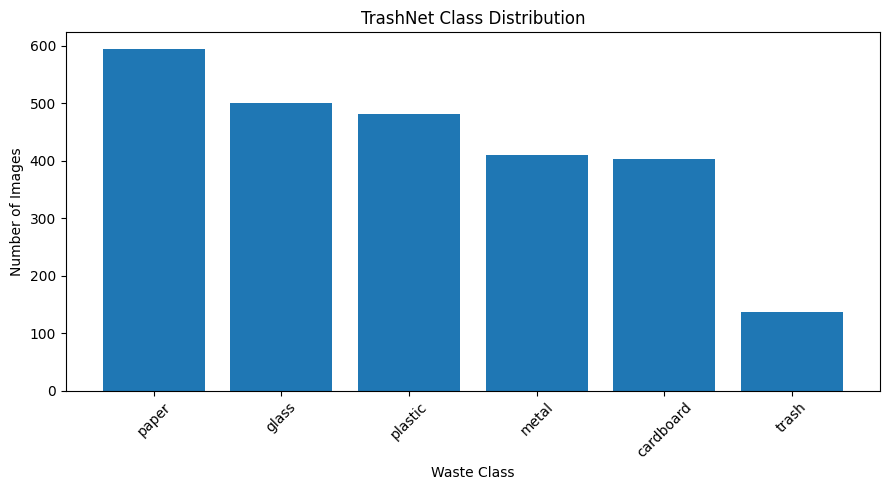

In [13]:
#class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Image Count"]
)

plt.title("TrashNet Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Class Distribution Observations

The dataset is moderately imbalanced.

This imbalance may cause trained models to perform better on classes with
more training examples and worse on the trash category. Therefore, overall
accuracy alone may not fully represent model performance. Per-class
precision, recall, F1-score, and confusion matrices will also be considered
during evaluation.

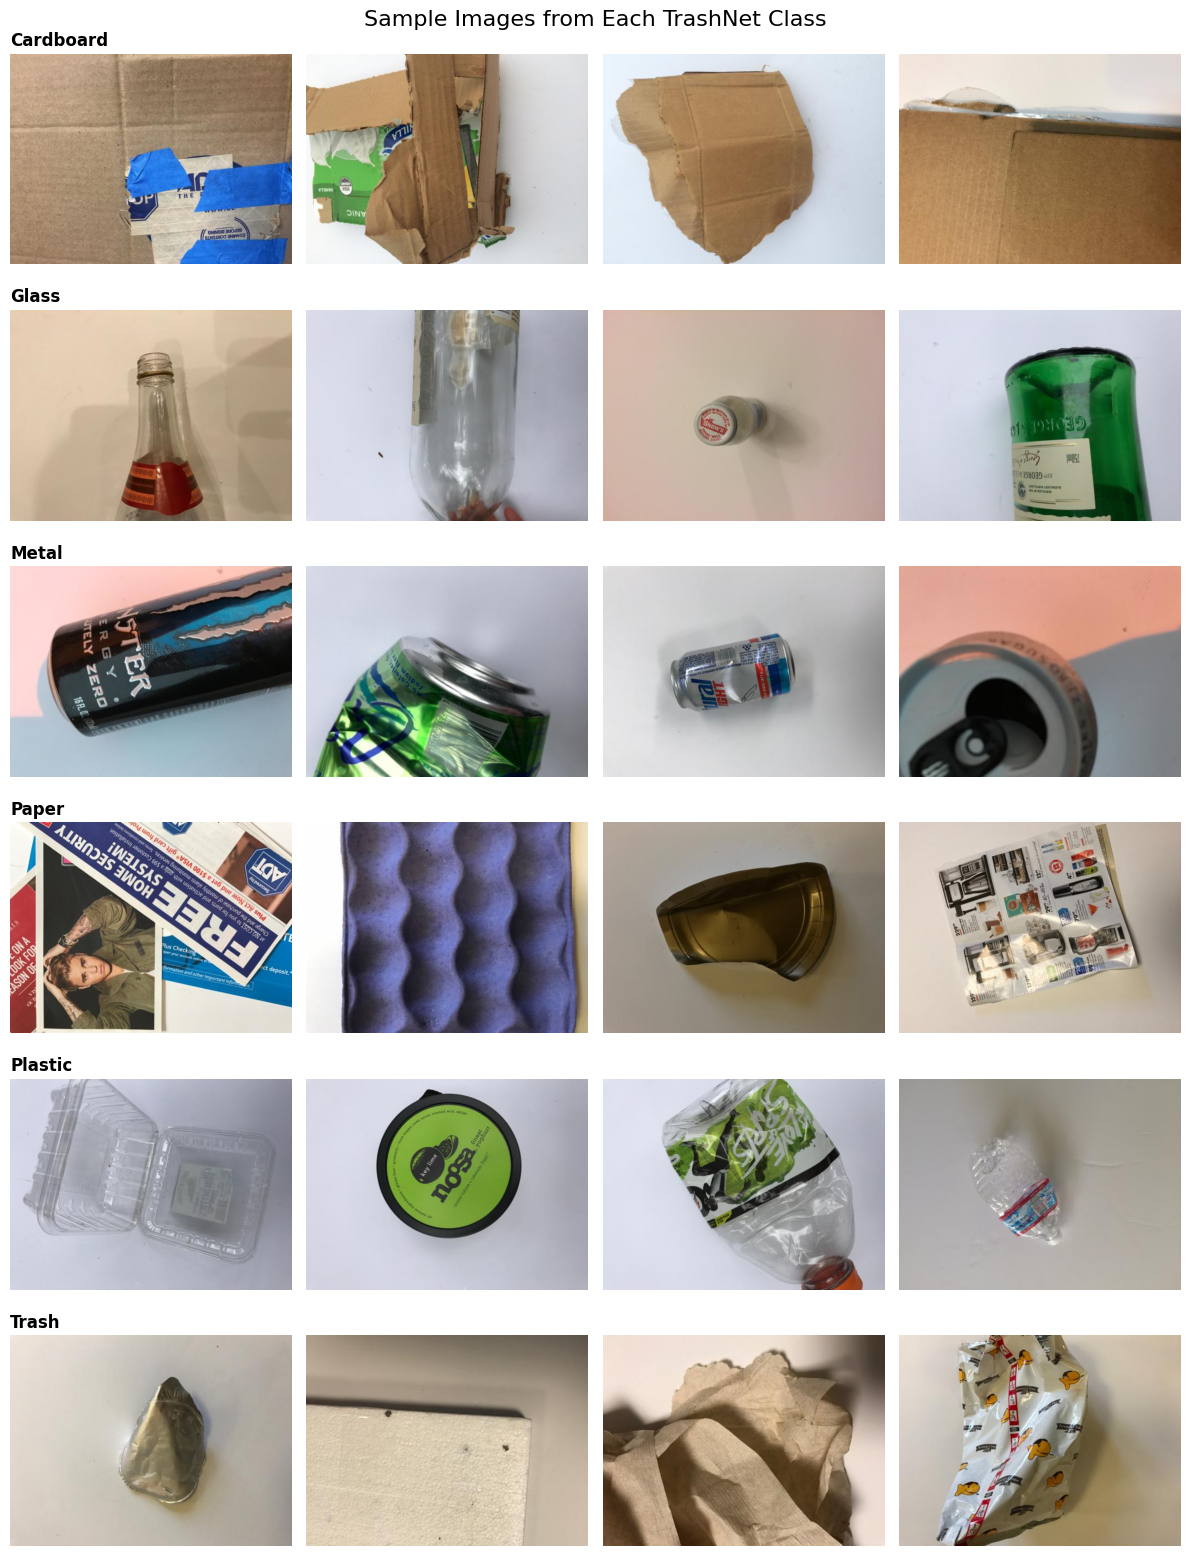

In [15]:
#display sample images

from PIL import Image
import random

fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=4,
    figsize=(12, 16)
)

for row, class_name in enumerate(class_names):

    class_path = DATASET_PATH / class_name
    image_files = list(class_path.glob("*.jpg"))

    selected_images = random.sample(image_files, 4)

    for col, image_path in enumerate(selected_images):

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(
                class_name.capitalize(),
                loc="left",
                fontweight="bold"
            )

plt.suptitle("Sample Images from Each TrashNet Class", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
image_dimensions = []

for class_name in class_names:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.glob("*.jpg"):

        with Image.open(image_path) as img:
            image_dimensions.append(img.size)

print("Image dimensions:", set(image_dimensions))

Image dimensions: {(512, 384)}


### EDA Summary

*  The TrashNet dataset contains 2,527 images distributed across six waste
categories: cardboard, glass, metal, paper, plastic, and trash.
*  The dataset exhibits class imbalance. Paper is the largest category, while
trash is smaller.
* model evaluation will include per-class precision, recall, F1-score, and confusion matrices in addition to overall accuracy.
* The images are consistently sized at 512 × 384 pixels and stored as RGB
images.
* images are all jpeg and have simple backgrounds. our real life image comparison will demonstrate comparisons in background variation, lighting, orientation, etc...

